# Epithelial Subclustering and Lineage Annotation

Epithelial cells are subset from the full annotated dataset and re-analyzed 
independently (fresh HVG selection, PCA, and clustering), since fine-grained 
epithelial heterogeneity is masked by major cell-type differences in the full-tissue 
analysis. Non-epithelial contamination in the initial subclustering is identified via 
marker genes and removed, followed by a final round of clustering and annotation into 
the three epithelial lineages described in Bhat-Nakshatri et al. 2021: basal/stem, 
luminal progenitor, and mature luminal.

In [1]:
import os
os.environ['NUMBA_NUM_THREADS'] = '64'

import scanpy as sc
import scanpy.external as sce
import numpy as np
import pandas as pd

sc.settings.verbosity = 1

adata_full = sc.read_h5ad('checkpoints/adata_full_annotated.h5ad')
print(adata_full)

/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


AnnData object with n_obs × n_vars = 45858 × 2000
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'sample', 'leiden', 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


## Subset epithelial cells and re-cluster

The epithelial subset is pulled from the full log-normalized gene set (`.raw`), not 
the HVG-restricted matrix, since a fresh HVG selection is needed for this subset.

Epithelial cells: 13247


/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-09-23 13:05:24,174 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-09-23 13:05:25,031 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-09-23 13:05:25,051 - harmonypy - INFO - Iteration 1 of 10
2026-09-23 13:05:26,103 - harmonypy - INFO - Iteration 2 of 10
2026-09-23 13:05:27,143 - harmonypy - INFO - Iteration 3 of 10
2026-09-23 13:05:28,148 - harmonypy - INFO - Iteration 4 of 10
2026-09-23 13:05:29,133 - harmonypy - INFO - Iteration 5 of 10
2026-09-23 13:05:30,146 - harmonypy - INFO - Iteration 6 of 10
2026-09-23 13:05:30,964 - harmonypy - INFO - Iteration 7 of 10
2026-09-23 13:05:31,808 - harmonypy - INFO - Iteration 8 of 10
2026-09-23 13:05:32,712 - harmonypy - INFO - Iteration 9 of 10
2026-09-23 13:05:33,752 - harmonypy - INFO - Iteration 10 of 1

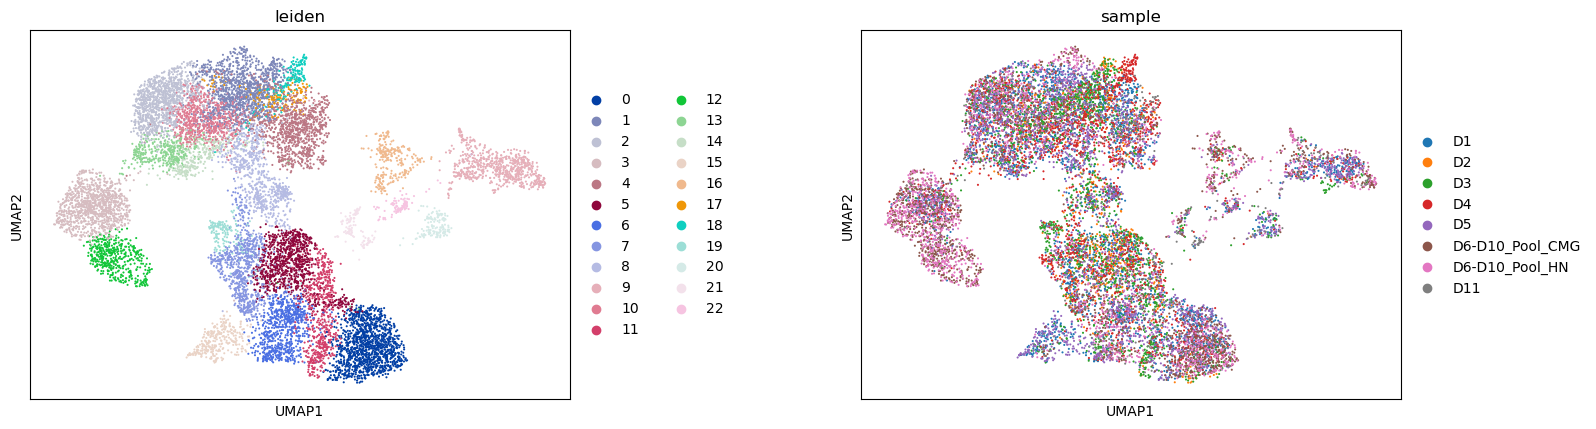

Number of clusters: 23


In [2]:
adata_epi = adata_full[adata_full.obs['cell_type'] == 'Epithelial'].copy()
adata_epi_full = adata_epi.raw.to_adata()
adata_epi_full.obs = adata_epi.obs

print(f"Epithelial cells: {adata_epi_full.n_obs}")

sc.pp.highly_variable_genes(adata_epi_full, n_top_genes=2000, batch_key='sample', flavor='seurat')

adata_epi_hvg = adata_epi_full[:, adata_epi_full.var['highly_variable']].copy()
adata_epi_hvg.raw = adata_epi_full

sc.pp.scale(adata_epi_hvg, max_value=10)
sc.tl.pca(adata_epi_hvg, svd_solver='arpack', n_comps=50)

sce.pp.harmony_integrate(adata_epi_hvg, 'sample')
sc.pp.neighbors(adata_epi_hvg, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata_epi_hvg)
sc.tl.leiden(adata_epi_hvg, resolution=1.5)

sc.pl.umap(adata_epi_hvg, color=['leiden', 'sample'], wspace=0.4)
print(f"Number of clusters: {adata_epi_hvg.obs['leiden'].nunique()}")

## Identify and remove non-epithelial contamination

A small number of clusters in the epithelial subset show strong non-epithelial 
markers (T cell, fibroblast, endothelial, myeloid), reflecting cells near the 
classification boundary in the major cell-type step. These are identified via 
cluster marker genes (Wilcoxon rank-sum, ribosomal/mitochondrial genes excluded) 
and removed before final annotation.

In [3]:
sc.tl.rank_genes_groups(adata_epi_hvg, groupby='leiden', method='wilcoxon', use_raw=True)

result_df = sc.get.rank_genes_groups_df(adata_epi_hvg, group=None)
mask = ~result_df['names'].str.startswith(('RPL', 'RPS', 'MT-'))
result_df_clean = result_df[mask]

top_markers = (
    result_df_clean
    .sort_values(['group', 'scores'], ascending=[True, False])
    .groupby('group')
    .head(8)
)

for cl in sorted(top_markers['group'].unique(), key=int):
    genes = top_markers[top_markers['group'] == cl]['names'].tolist()
    print(f"Cluster {cl}: {', '.join(genes)}")

/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/scanpy/tools/_rank_gene

Cluster 0: RACK1, GAPDH, SFRP1, NACA, UQCRH, FAU, HINT1, BTF3
Cluster 1: XBP1, KLF6, VMP1, AREG, BATF, SAT1, TCIM, NEAT1
Cluster 2: AZGP1, ANKRD30A, MALAT1, XBP1, ADIRF, CST3, TPM1, GATA3
Cluster 3: CSN3, FABP3, CIDEA, LYZ, CEL, CSN1S1, SPP1, CHRDL2
Cluster 4: PIP, MUCL1, XBP1, TFF3, AZGP1, MGP, SLC39A6, SUB1
Cluster 5: SLPI, RCAN1, KRT15, RGS2, ANXA1, CRYAB, CXCL2, NR4A1
Cluster 6: SFRP1, RACK1, PIGR, MFGE8, PLCG2, KRT15, GAPDH, SLC12A2
Cluster 7: LY6E, KRT7, S100A6, MGP, ANXA1, RARRES1, SLPI, KRT15
Cluster 8: AREG, KLF6, EGR1, UGDH, YWHAG, MYC, VMP1, NR4A1
Cluster 9: CXCL14, TAGLN, ACTA2, MYLK, MYL9, C2orf40, TPM2, PPP1R14A
Cluster 10: FOS, JUNB, ANKRD30A, XBP1, MALAT1, JUN, KRT18, SOCS3
Cluster 11: CALML5, SNORC, SFRP1, SCGB1D2, SLPI, SCGB2A1, KRT15, SCGB2A2
Cluster 12: XDH, CEL, OLAH, G0S2, SPP1, CSN1S1, MUC4, LYZ
Cluster 13: XBP1, TMSB4X, AZGP1, SERF2, ANKRD30A, HMGN1, ADIRF, SAT1
Cluster 14: HNRNPH1, MALAT1, CTNNB1, ATP1B1, NEAT1, ANKRD30A, XBP1, AREG
Cluster 15: PCLAF, TOP2A, TU

Clusters showing clear non-epithelial identity (e.g. PTPRC/CD3D for T cells, 
COL1A2/DCN for fibroblasts, CAV1/CD36 for endothelial/adipocyte, HLA-DRA/CD74 for 
myeloid) are removed, and the pipeline is re-run on the clean epithelial subset.

Before: 13247 | After removing contaminants: 12466


/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-09-23 14:14:03,474 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-09-23 14:14:04,288 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-09-23 14:14:04,309 - harmonypy - INFO - Iteration 1 of 10
2026-09-23 14:14:05,259 - harmonypy - INFO - Iteration 2 of 10
2026-09-23 14:14:06,241 - harmonypy - INFO - Iteration 3 of 10
2026-09-23 14:14:07,194 - harmonypy - INFO - Iteration 4 of 10
2026-09-23 14:14:08,174 - harmonypy - INFO - Iteration 5 of 10
2026-09-23 14:14:09,128 - harmonypy - INFO - Iteration 6 of 10
2026-09-23 14:14:10,101 - harmonypy - INFO - Iteration 7 of 10
2026-09-23 14:14:10,861 - harmonypy - INFO - Iteration 8 of 10
2026-09-23 14:14:11,836 - harmonypy - INFO - Iteration 9 of 10
2026-09-23 14:14:12,545 - harmonypy - INFO - Iteration 10 of 1

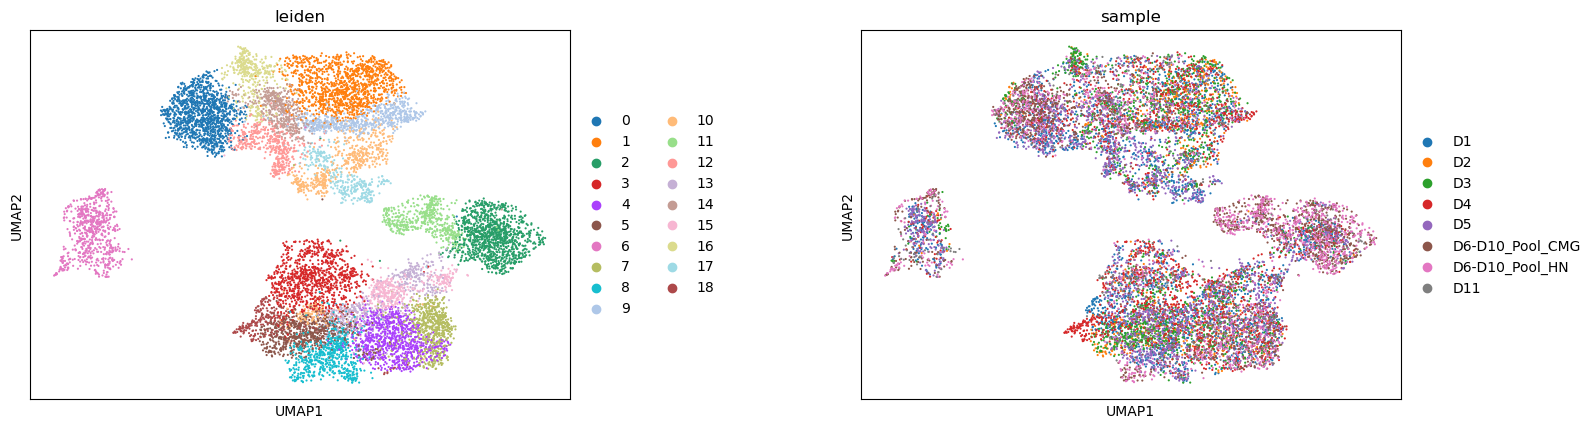

Number of clean epithelial clusters: 19


In [4]:
contaminant_clusters = ['16', '19', '20', '21', '22']

adata_epi_clean = adata_epi_full[~adata_epi_hvg.obs['leiden'].isin(contaminant_clusters)].copy()
print(f"Before: {adata_epi_hvg.n_obs} | After removing contaminants: {adata_epi_clean.n_obs}")

sc.pp.highly_variable_genes(adata_epi_clean, n_top_genes=2000, batch_key='sample', flavor='seurat')

adata_epi_clean_hvg = adata_epi_clean[:, adata_epi_clean.var['highly_variable']].copy()
adata_epi_clean_hvg.raw = adata_epi_clean

sc.pp.scale(adata_epi_clean_hvg, max_value=10)
sc.tl.pca(adata_epi_clean_hvg, svd_solver='arpack', n_comps=50)

sce.pp.harmony_integrate(adata_epi_clean_hvg, 'sample')
sc.pp.neighbors(adata_epi_clean_hvg, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata_epi_clean_hvg)
sc.tl.leiden(adata_epi_clean_hvg, resolution=1.5)

sc.pl.umap(adata_epi_clean_hvg, color=['leiden', 'sample'], wspace=0.4)
print(f"Number of clean epithelial clusters: {adata_epi_clean_hvg.obs['leiden'].nunique()}")

## Lineage annotation

Cluster markers are re-computed on the clean epithelial set and matched against 
marker genes reported in Bhat-Nakshatri et al. 2021 (Figures 1D, 2, 3) to assign 
each cluster to one of the three epithelial lineages.

In [5]:
sc.tl.rank_genes_groups(adata_epi_clean_hvg, groupby='leiden', method='wilcoxon', use_raw=True)

result_df = sc.get.rank_genes_groups_df(adata_epi_clean_hvg, group=None)
mask = ~result_df['names'].str.startswith(('RPL', 'RPS', 'MT-'))
result_df_clean = result_df[mask]

top_markers = (
    result_df_clean
    .sort_values(['group', 'scores'], ascending=[True, False])
    .groupby('group')
    .head(8)
)

for cl in sorted(top_markers['group'].unique(), key=int):
    genes = top_markers[top_markers['group'] == cl]['names'].tolist()
    print(f"Cluster {cl}: {', '.join(genes)}")

Cluster 0: RACK1, GAPDH, NACA, FAU, UQCRH, SFRP1, HINT1, BTF3
Cluster 1: SLPI, KRT15, CRYAB, S100A6, ANXA1, RCAN1, RGS2, CCL28
Cluster 2: CIDEA, CSN3, CEL, FABP3, LYZ, SPP1, CSN1S1, CHRDL2
Cluster 3: PIP, MUCL1, XBP1, TFF3, AZGP1, MGP, SUB1, SLC39A6
Cluster 4: GATA3, ANKRD30A, MALAT1, XBP1, JUNB, FOS, AZGP1, KRT18
Cluster 5: XBP1, STC2, ATF3, MAFF, IER3, VMP1, ELF3, RUNX1
Cluster 6: CXCL14, TAGLN, ACTA2, MYLK, MYL9, C2orf40, TPM2, PPP1R14A
Cluster 7: ANKRD30A, AZGP1, MALAT1, ADIRF, XBP1, CST3, GATA3, TPM1
Cluster 8: CXCL13, XBP1, AREG, COX6C, TFF3, TCIM, PTHLH, SLC26A3
Cluster 9: LY6E, S100A6, MGP, KRT7, ANXA1, SLPI, RARRES1, LTF
Cluster 10: GABRP, KIT, CALD1, CXCL2, PHLDA1, APP, YWHAG, EEF1A1
Cluster 11: XDH, CEL, G0S2, OLAH, SPP1, CSN1S1, LYZ, CIDEA
Cluster 12: RACK1, INSR, PIGR, CTNNB1, SLC25A6, SFRP1, SLC12A2, CRABP1
Cluster 13: HNRNPH1, CTNNB1, ATP1B1, CDC42, C1orf56, XBP1, MALAT1, EIF5A
Cluster 14: SFRP1, MTRNR2L8, PLCG2, MTRNR2L12, MFGE8, KRT15, NDRG2, GAPDH
Cluster 15: TMSB4X, 

/tmp/ipykernel_2439945/821636880.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('group')


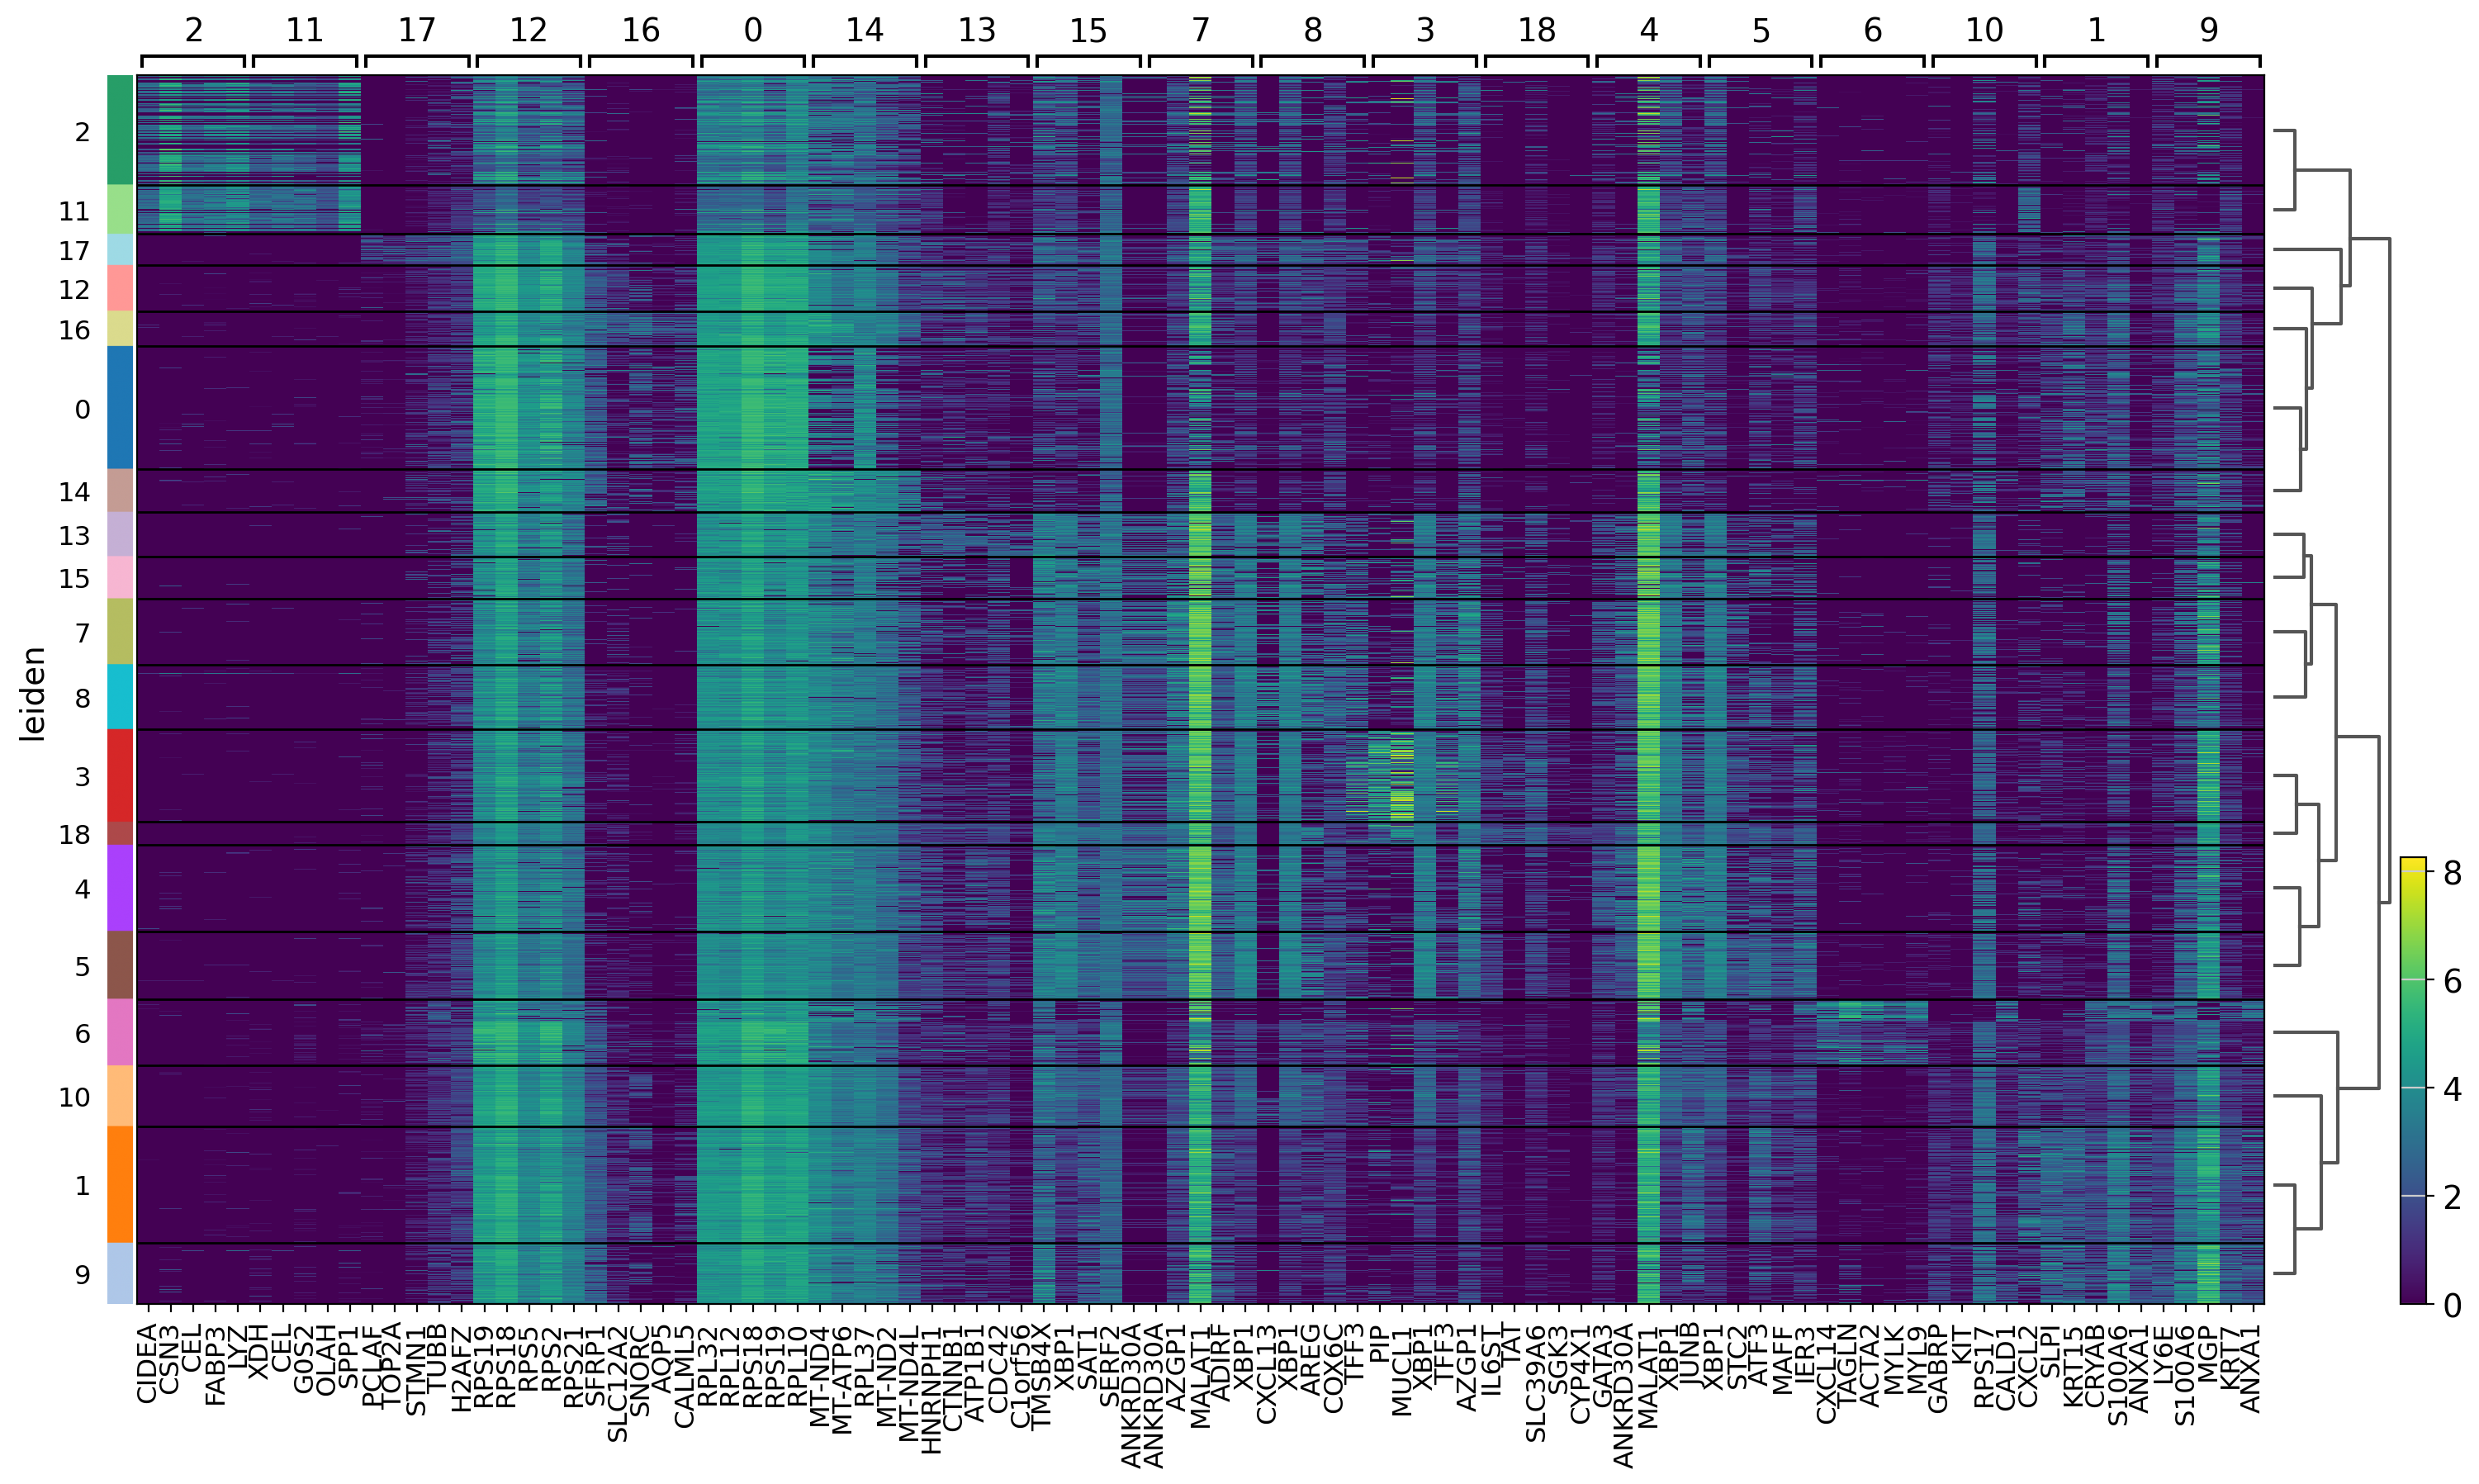

In [14]:
sc.pl.rank_genes_groups_heatmap(
    adata_epi_clean_hvg, 
    n_genes=5,   
    show_gene_labels=True,
    figsize=(18, 10)
)

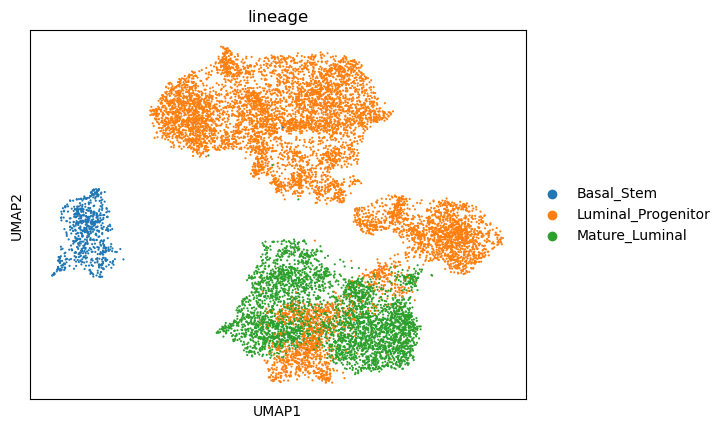

lineage
Luminal_Progenitor    7958
Mature_Luminal        3832
Basal_Stem             676
Name: count, dtype: int64


In [6]:
# Update this mapping based on your own run's marker output —
# see paper markers: CXCL14/ACTA2 (basal), SFRP1/SLPI/KIT/CALML5 (luminal progenitor),
# PIP/MUCL1/ANKRD30A/XBP1/STC2 (mature luminal)
lineage_annotation = {
    '0': 'Luminal_Progenitor', '1': 'Luminal_Progenitor', '2': 'Luminal_Progenitor',
    '3': 'Mature_Luminal', '4': 'Mature_Luminal', '5': 'Mature_Luminal',
    '6': 'Basal_Stem', '7': 'Mature_Luminal', '8': 'Luminal_Progenitor',
    '9': 'Luminal_Progenitor', '10': 'Luminal_Progenitor', '11': 'Luminal_Progenitor',
    '12': 'Luminal_Progenitor', '13': 'Luminal_Progenitor', '14': 'Luminal_Progenitor',
    '15': 'Mature_Luminal', '16': 'Luminal_Progenitor', '17': 'Luminal_Progenitor',
    '18': 'Mature_Luminal',
}

adata_epi_clean_hvg.obs['lineage'] = adata_epi_clean_hvg.obs['leiden'].map(lineage_annotation)

sc.pl.umap(adata_epi_clean_hvg, color='lineage', legend_loc='right margin')
print(adata_epi_clean_hvg.obs['lineage'].value_counts())

## Save checkpoint

In [7]:
adata_epi_clean_hvg.write('checkpoints/adata_epithelial_annotated.h5ad')